# Semantic Search Engine using Word2Vec, SBERT and Hybrid Retrieval

Dataset:
- MS MARCO
- 200K Queries
- ~2M Passages

Models:
1. Word2Vec + Query Expansion
2. SBERT + FAISS
3. Hybrid Retrieval + Reranking

Evaluation:
- Precision@K
- Recall@K
- F1@K
- MRR
- NDCG

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 52.1 MB/s eta 0:00:00


In [ ]:
from datasets import load_dataset, DownloadConfig
from tqdm import tqdm
import re
import pickle
import os
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import gc


import numpy as np
import pandas as pd
from gensim.models import Word2Vec

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#**Loading Data**

In [ ]:
# Project folders in Drive
PROJECT_DIR = "/content/drive/MyDrive/CS328_Project_new"
HF_DATASETS_CACHE = os.path.join(PROJECT_DIR, "hf_datasets_cache")
OUTPUT_DIR = os.path.join(PROJECT_DIR, "outputs")

# Create folders if they don't exist
for path in [PROJECT_DIR, HF_DATASETS_CACHE, OUTPUT_DIR]:
    os.makedirs(path, exist_ok=True)

# Tell Hugging Face to use Drive for all cache
os.environ["HF_DATASETS_CACHE"] = HF_DATASETS_CACHE

# Optional authentication for better reliability / fewer rate-limit issues
HF_TOKEN = None

try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    HF_TOKEN = os.environ.get("HF_TOKEN", None)

if HF_TOKEN:
    try:
        from huggingface_hub import login
        login(token=HF_TOKEN, add_to_git_credential=False)
        print("Hugging Face login successful.")
    except Exception as e:
        print("HF login failed, continuing unauthenticated.")
        print("Reason:", e)
else:
    print("No HF_TOKEN found. Continuing without login.")

# Robust download configuration
download_config = DownloadConfig(
    resume_download=True,
    max_retries=10
)

# Load MS MARCO train split with cache reuse
print("Loading MS MARCO dataset...")
dataset = load_dataset(
    "microsoft/ms_marco",
    "v2.1",
    split="train",
    cache_dir=HF_DATASETS_CACHE,
    download_config=download_config,
    download_mode="reuse_dataset_if_exists"
)

Hugging Face login successful.
Loading MS MARCO dataset...


README.md: 0.00B [00:00, ?B/s]

In [ ]:
NUM_SAMPLES = 200_000
dataset = dataset.select(range(min(NUM_SAMPLES, len(dataset))))

# Quick sanity checks
print(f"Loaded {len(dataset)} samples")
print(f"Sample keys: {list(dataset[0].keys())}")
print(f"Sample query: {dataset[0]['query']}")
print(f"Number of passages in sample 0: {len(dataset[0]['passages']['passage_text'])}")
print(f"HF_DATASETS_CACHE: {HF_DATASETS_CACHE}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

Loaded 200000 samples
Sample keys: ['answers', 'passages', 'query', 'query_id', 'query_type', 'wellFormedAnswers']
Sample query: )what was the immediate impact of the success of the manhattan project?
Number of passages in sample 0: 10
HF_DATASETS_CACHE: /content/drive/MyDrive/CS328_Project_new/hf_datasets_cache
OUTPUT_DIR: /content/drive/MyDrive/CS328_Project_new/outputs


In [ ]:
passages_flat = []
passage_meta  = []
queries       = []

for idx, sample in enumerate(tqdm(dataset, desc="Extracting")):
    texts  = sample['passages']['passage_text']
    labels = sample['passages']['is_selected']

    queries.append({
        'query'      : sample['query'],
        'query_id'   : sample['query_id'],
        'sample_idx' : idx,
        'passages'   : texts,
        'labels'     : labels
    })

    for p_text, p_label in zip(texts, labels):
        passages_flat.append(p_text)
        passage_meta.append({
            'sample_idx' : idx,
            'is_selected': int(p_label),
            'query_id'   : sample['query_id']
        })
print()
print(f"Total passages: {len(passages_flat)}")
print(f"Total queries : {len(queries)}")

Extracting: 100%|██████████| 200000/200000 [00:38<00:00, 5147.80it/s]


Total passages: 1995277
Total queries : 200000


#**Preprocessing the data**

In [ ]:
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

STOP_WORDS = set(stopwords.words('english'))

SAVE_DIR = OUTPUT_DIR
os.makedirs(SAVE_DIR, exist_ok=True)

def preprocess(text):
    text   = text.lower()
    text   = re.sub(r'[^\w\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOP_WORDS and t.isalpha()]
    return tokens

# Batch settings
BATCH_SIZE = 5_00_000
total      = len(passages_flat)
n_batches  = (total + BATCH_SIZE - 1) // BATCH_SIZE
print(f"Total passages : {total}")
print(f"Batch size     : {BATCH_SIZE}")
print(f"Total batches  : {n_batches}")

Total passages : 1995277
Batch size     : 500000
Total batches  : 4


In [ ]:
# ── Process each batch and save separately to Drive ─────────
for batch_num in range(n_batches):
    batch_path = os.path.join(SAVE_DIR, f'tokenized_batch_{batch_num}.pkl')

    # Skip if this batch already done (crash recovery!)
    if os.path.exists(batch_path):
        print(f"Batch {batch_num+1}/{n_batches} already exists, skipping...")
        continue

    start = batch_num * BATCH_SIZE
    end   = min(start + BATCH_SIZE, total)
    batch = passages_flat[start:end]

    print(f"\nProcessing batch {batch_num+1}/{n_batches} "
          f"(passages {start} → {end})...")

    tokenized_batch = [preprocess(p) for p in tqdm(batch)]

    with open(batch_path, 'wb') as f:
        pickle.dump(tokenized_batch, f)

    print(f"Batch {batch_num+1} saved to Drive ✓")
    del batch
    del tokenized_batch
    gc.collect()

print("\nAll batches done!")

Batch 1/4 already exists, skipping...
Batch 2/4 already exists, skipping...
Batch 3/4 already exists, skipping...
Batch 4/4 already exists, skipping...

All batches done!


##**Building Word2vec model**

In [ ]:
w2v_path = os.path.join(OUTPUT_DIR, 'word2vec.model')

class BatchSentenceIterator:
    def __init__(self, save_dir, n_batches):
        self.save_dir = save_dir
        self.n_batches = n_batches

    def __iter__(self):
        for batch_num in range(self.n_batches):
            batch_path = os.path.join(self.save_dir, f'tokenized_batch_{batch_num}.pkl')
            print(f"  Feeding batch {batch_num+1}/{self.n_batches}...")
            with open(batch_path, 'rb') as f:
                batch = pickle.load(f)
            for sentence in batch:
                yield sentence

sentences = BatchSentenceIterator(SAVE_DIR, n_batches)

if os.path.exists(w2v_path):
    print("Loading existing model...")
    w2v_model = Word2Vec.load(w2v_path)
else:
    print("Training Word2Vec on all batches...")
    w2v_model = Word2Vec(
        vector_size=300,
        window=5,
        min_count=2,
        workers=1,
        epochs=5
    )

    w2v_model.build_vocab(sentences)

    w2v_model.train(
        sentences,
        total_examples=w2v_model.corpus_count,
        epochs=w2v_model.epochs
    )

    w2v_model.save(w2v_path)
    print("Word2Vec model saved to Drive ✓")

print("Done!")

Loading existing model...
Done!


In [ ]:
print(f"Vocabulary size : {len(w2v_model.wv)}")
print(f"Vector size     : {w2v_model.vector_size}")
print(f"Nearest to 'climate' : {w2v_model.wv.most_similar('climate', topn=3)}")
print(f"Nearest to 'car'     : {w2v_model.wv.most_similar('car',     topn=3)}")

Vocabulary size : 414512
Vector size     : 300
Nearest to 'climate' : [('climatic', 0.5637439489364624), ('climates', 0.5515906810760498), ('weather', 0.5489806532859802)]
Nearest to 'car'     : [('cars', 0.7871779203414917), ('vehicle', 0.7272387146949768), ('vehicles', 0.6085280776023865)]


In [ ]:
# ---------------------------------------------------------
# count total passages across all tokenized batches
# ---------------------------------------------------------
Total_tokenized_passages = len(passages_flat)
print("Total passages:", Total_tokenized_passages)

Total passages: 1995277


##**Embedding the passages using word2vec model**

In [ ]:
# FINAL WORD2VEC DOCUMENT EMBEDDING CODE

DIM = w2v_model.vector_size

EMBED_PATH = os.path.join(OUTPUT_DIR, "doc_embeddings.dat")   # memmap file
IDS_PATH   = os.path.join(OUTPUT_DIR, "doc_ids.npy")          # maps embedding row -> original passage index



# Helper: convert one token list -> one document vector
def get_doc_vector(tokens, w2v_model):
    vecs = [w2v_model.wv[t] for t in tokens if t in w2v_model.wv]
    if not vecs:
        return None
    return np.mean(vecs, axis=0).astype(np.float32)


# Main builder function

def build_doc_embeddings(save_dir, n_batches, w2v_model,
                         embed_path, ids_path, dim):

    # If already built, skip recomputation
    if os.path.exists(embed_path) and os.path.exists(ids_path):
        print("Document embeddings already exist. Skipping creation.")
        print(f"Embeddings file : {embed_path}")
        print(f"Doc IDs file    : {ids_path}")
        return None

    total_passages = Total_tokenized_passages

    print("\nCreating memmap file on disk...")
    embeddings_mm = np.memmap(
        embed_path,
        dtype="float32",
        mode="w+",
        shape=(total_passages, dim)
    )

    doc_ids_list = []
    row = 0
    global_passage_id = 0

    print("\nGenerating document embeddings batch-by-batch...")
    for batch_num in range(n_batches):
        batch_path = os.path.join(save_dir, f"tokenized_batch_{batch_num}.pkl")
        print(f"\nProcessing batch {batch_num + 1}/{n_batches} -> {batch_path}")

        with open(batch_path, "rb") as f:
            tokenized_batch = pickle.load(f)

        for tokens in tqdm(tokenized_batch, desc=f"Batch {batch_num+1}", leave=False):
            doc_vec = get_doc_vector(tokens, w2v_model)

            # Skip passages with no valid words in vocab
            if doc_vec is None:
                global_passage_id += 1
                continue

            embeddings_mm[row] = doc_vec
            doc_ids_list.append(global_passage_id)

            row += 1
            global_passage_id += 1

        del tokenized_batch
        embeddings_mm.flush()
        gc.collect()

        print(f"Batch {batch_num + 1} flushed to disk. Current valid docs: {row:,}")

    # Save ID mapping
    doc_ids = np.array(doc_ids_list, dtype=np.int64)
    np.save(ids_path, doc_ids)

    del embeddings_mm
    del doc_ids
    del doc_ids_list
    gc.collect()

    print("\n===================================================")
    print("Document embedding creation finished.")
    print(f"Saved embeddings : {embed_path}")
    print(f"Saved doc IDs    : {ids_path}")
    print(f"Valid shape      : ({row:,}, {dim})")
    print("===================================================")

    return None


# Run

build_doc_embeddings(save_dir=SAVE_DIR,n_batches=n_batches,
    w2v_model=w2v_model,embed_path=EMBED_PATH,
    ids_path=IDS_PATH,
    dim=DIM
)


Document embeddings already exist. Skipping creation.
Embeddings file : /content/drive/MyDrive/CS328_Project_new/outputs/doc_embeddings.dat
Doc IDs file    : /content/drive/MyDrive/CS328_Project_new/outputs/doc_ids.npy


In [ ]:
# Load doc_ids (this tells how many valid embeddings exist)
doc_ids = np.load(IDS_PATH)

valid_docs = len(doc_ids)
dim        = DIM
total_passages = Total_tokenized_passages

meta = {
    "valid_docs": valid_docs,
    "dim": dim,
    "total_passages": total_passages
}
embeddings = np.memmap(EMBED_PATH, dtype="float32", mode="r", shape=(valid_docs, DIM))

print("\n================ METADATA =================")
print(f"Valid document embeddings : {valid_docs:,}")
print(f"Embedding dimension       : {dim}")
print(f"Total passages            : {total_passages:,}")
print("===========================================")


================ METADATA =================
Valid document embeddings : 1,995,141
Embedding dimension       : 300
Total passages            : 1,995,277


#**Fiass Indexing for Woerd2vec model passage embedings**

In [ ]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 23.2 MB/s eta 0:00:00


In [ ]:
import faiss

In [ ]:
INDEX_PATH = os.path.join(OUTPUT_DIR, "faiss_index_word2vec.bin")

CHUNK_SIZE = 50_000
DIM = embeddings.shape[1]

if os.path.exists(INDEX_PATH):
    print("FAISS FlatIP index already exists. Loading from Drive...")
    index = faiss.read_index(INDEX_PATH)
    print(f"Loaded FAISS index with {index.ntotal:,} vectors")
else:
    print("Building FAISS IndexFlatIP index...")

    # Exact inner-product search
    index = faiss.IndexFlatIP(DIM)

    print("Adding vectors to FAISS index...")

    for start in tqdm(range(0, valid_docs, CHUNK_SIZE)):
        end = min(start + CHUNK_SIZE, valid_docs)

        chunk = np.array(embeddings[start:end], dtype="float32")
        faiss.normalize_L2(chunk)   # important for cosine similarity
        index.add(chunk)

        del chunk

    print(f"\nFAISS FlatIP index built. Total vectors: {index.ntotal:,}")

    faiss.write_index(index, INDEX_PATH)
    print(f"FAISS index saved → {INDEX_PATH}")

FAISS FlatIP index already exists. Loading from Drive...
Loaded FAISS index with 1,995,141 vectors


###**Query Encoder**

In [ ]:
import re
import numpy as np
import faiss
import nltk
from gensim.models import Word2Vec

nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords


class QueryEncoder:
    """
    QueryEncoder for Design 1 (Word2Vec + Query Expansion)

    Pipeline:
    query text
      -> preprocess
      -> query expansion using Word2Vec most_similar
      -> weighted averaging of vectors
      -> L2 normalize
      -> return (1, DIM) vector ready for FAISS
    """

    def __init__(self,
                 w2v_model: Word2Vec,
                 dim: int = 300,
                 expansion_topn: int = 5,
                 min_similarity: float = 0.5,
                 original_weight: float = 1.0,
                 expanded_weight: float = 0.7):
        """
        Parameters
        ----------
        w2v_model : trained Word2Vec model
        dim : embedding dimension (300)
        expansion_topn : number of similar words per token
        min_similarity : filter weak neighbors
        original_weight : weight for original query tokens
        expanded_weight : weight for expanded tokens
        """
        self.model = w2v_model
        self.dim = dim
        self.expansion_topn = expansion_topn
        self.min_similarity = min_similarity
        self.original_weight = original_weight
        self.expanded_weight = expanded_weight
        self.stopwords = set(stopwords.words("english"))

    # preprocessing the query text

    def _preprocess(self, text: str) -> list:
        text = text.lower()
        text = re.sub(r"[^\w\s]", "", text)
        tokens = text.split()
        tokens = [t for t in tokens if t not in self.stopwords and len(t) > 1]
        return tokens

    #expansion of tokens

    def _expand_tokens(self, tokens: list) -> list:
        expanded = []

        for word in tokens:
           # skipping the word that not present in the model
            if word not in self.model.wv:
                continue

            try:
               #finding the nearest vectors to words in the query text
                neighbors = self.model.wv.most_similar(word, topn=self.expansion_topn)
                for neigh_word, sim in neighbors:
                    if sim >= self.min_similarity:
                        expanded.append(neigh_word)
            except KeyError:
                continue

        # remove duplicates
        seen = set()
        final = []
        for w in expanded:
            if w not in seen:
                seen.add(w)
                final.append(w)

        return final

    #query encoding part

    def encode(self, query: str) -> np.ndarray | None:
        tokens = self._preprocess(query)

        if not tokens:
            print(f"[QueryEncoder] WARNING: query empty after preprocessing: '{query}'")
            return None

        expanded_tokens = self._expand_tokens(tokens)

        vecs = []

        # here we make sure that we are giving more priority such that expanded words doesnt dominate original tokens
        # original tokens (higher weight)
        for t in tokens:
            if t in self.model.wv:
                vecs.append(self.original_weight * self.model.wv[t])

        # expanded tokens (lower weight)
        for t in expanded_tokens:
            if t in self.model.wv:
                vecs.append(self.expanded_weight * self.model.wv[t])

        if not vecs:
            print(f"[QueryEncoder] WARNING: no vocab match for '{query}'")
            return None

        vec = np.mean(vecs, axis=0).astype("float32")
        vec = vec.reshape(1, -1)
        faiss.normalize_L2(vec)

        return vec

    def debug_expand(self, query: str):
        tokens = self._preprocess(query)
        expanded = self._expand_tokens(tokens)

        print("Original tokens :", tokens)
        print("Expanded tokens :", expanded)
        print("Total expanded  :", len(expanded))

In [ ]:
# STEP 7: Create QueryEncoder object
encoder = QueryEncoder(
    w2v_model=w2v_model,
    dim=300,
    expansion_topn=5
)

#debugging the queryvector code
encoder.debug_expand("global warming effects on sea level")

Original tokens : ['global', 'warming', 'effects', 'sea', 'level']
Expanded tokens : ['industrys', 'chinas', 'worldwide', 'globally', 'unep', 'warmingcarbon', 'greenhouse', 'warminghe', 'effect', 'sideeffects', 'effectsit', 'effectsedit', 'effectshe', 'ocean', 'seas', 'seathe', 'caspian', 'seabed', 'levels']
Total expanded  : 19


###**Search function to get top k passages using word2vec**

In [ ]:
def search(query, k=10):
    qvec = encoder.encode(query)

    if qvec is None:
        print(f"[WARNING] No vocab match for query: {query}")
        return []

    # We search for k*5 to ensure we find enough UNIQUE passages
    scores, faiss_rows = index.search(qvec, k*5)

    results = []
    seen_texts = set() # ADDED for uniqueness

    for row, score in zip(faiss_rows[0], scores[0]):
        if row == -1:
            continue

        passage_id = int(doc_ids[row])
        text = passages_flat[passage_id] # FULL paragraph

        # Check if we have seen this text before (even with different ID)
        content_key = text.strip().lower()
        if content_key not in seen_texts:
            seen_texts.add(content_key)
            results.append({
                "rank": len(results) + 1,
                "passage_id": passage_id,
                "score": float(score),
                "text": text # Full text
            })

        if len(results) == k:
            break

    return results

In [ ]:
query = "global warming effects on sea level"
hits = search(query, k=5)

print("Query:", query)
for h in hits:
    print(h)

Query: global warming effects on sea level
{'rank': 1, 'passage_id': 804893, 'score': 0.8365943431854248, 'text': '8. Climate change and issues related to global warming, such as the greenhouse effect, global dimming, and the gradual rise in sea level. 9. Consumerism and over-consumption and their effect on the planet.'}
{'rank': 2, 'passage_id': 804889, 'score': 0.7929078340530396, 'text': '1 Climate change — Global warming • Global dimming • Fossil fuels • Sea level rise • Greenhouse gas • Ocean acidification • Shutdown of thermohaline circulation • Environmental impact of the coal industry • Urban Heat Islands • Flooding.'}
{'rank': 3, 'passage_id': 1363769, 'score': 0.7837898135185242, 'text': 'Global Warming Science and Impacts. The causes and consequences of rising global temperatures. The effects of rising temperatures are already being felt across the United States and around the world, with serious implications for our health, our environment, and our economy. Dangerous heat w

#**SBERT Model**

In [ ]:
!pip install sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np
import os
import pickle
from tqdm import tqdm
import gc

In [ ]:
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')  # fast + good
DIM = 384  # SBERT embedding size

print("SBERT model loaded!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

SBERT model loaded!


In [ ]:
EMBED_PATH_SBERT = os.path.join(OUTPUT_DIR, "sbert_embeddings.dat")
META_PATH_SBERT  = os.path.join(OUTPUT_DIR, "sbert_meta.npy")
IDS_PATH_SBERT   = os.path.join(OUTPUT_DIR, "sbert_ids.npy")

###**Embedding passages using sbert**

In [ ]:
import os
import gc
import numpy as np
from tqdm import tqdm

# SBERT Embedding Generation (Run only once)

BATCH_SIZE = 512
TOTAL = Total_tokenized_passages

# If already exists, skip regeneration
if os.path.exists(EMBED_PATH_SBERT) and os.path.exists(IDS_PATH_SBERT) and os.path.exists(META_PATH_SBERT):
    print("SBERT embeddings already exist. Skipping generation.")

    meta = np.load(META_PATH_SBERT)
    doc_ids_sbert = np.load(IDS_PATH_SBERT)

    print("Loaded meta:", meta)
    print("Embeddings file:", EMBED_PATH_SBERT)
    print("Total doc_ids:", len(doc_ids_sbert))

else:
    print("Generating SBERT embeddings...")

    # Create memmap file (overwrites if not exists)
    embeddings_mm_sbert = np.memmap(
        EMBED_PATH_SBERT,
        dtype="float32",
        mode="w+",
        shape=(TOTAL, DIM)
    )

    # doc_ids = row index
    doc_ids_sbert = np.arange(TOTAL, dtype=np.int32)

    row = 0

    for i in tqdm(range(0, TOTAL, BATCH_SIZE), desc="Encoding passages with SBERT"):
        batch_texts = passages_flat[i:i+BATCH_SIZE]

        emb = sbert_model.encode(
            batch_texts,
            batch_size=BATCH_SIZE,
            show_progress_bar=False,
            convert_to_numpy=True
        ).astype("float32")

        # Normalize for cosine similarity (recommended)
        norms = np.linalg.norm(emb, axis=1, keepdims=True)
        emb = emb / (norms + 1e-10) # used to handle if any embedding norm=0

        embeddings_mm_sbert[row:row+len(batch_texts)] = emb
        row += len(batch_texts)

        if i % (BATCH_SIZE * 20) == 0:
            embeddings_mm_sbert.flush()
            gc.collect()

    embeddings_mm_sbert.flush()

    # Save IDs + metadata
    np.save(IDS_PATH_SBERT, doc_ids_sbert)
    np.save(META_PATH_SBERT, np.array([TOTAL, DIM], dtype=np.int32))

    print("SBERT embeddings created!")
    print("Shape:", (TOTAL, DIM))


SBERT embeddings already exist. Skipping generation.
Loaded meta: [1995277     384]
Embeddings file: /content/drive/MyDrive/CS328_Project_new/outputs/sbert_embeddings.dat
Total doc_ids: 1995277


In [ ]:
# Load embeddings (for future use)
doc_ids_sbert = np.load(IDS_PATH_SBERT)
meta = np.load(META_PATH_SBERT)

N = len(doc_ids_sbert)

embeddings_sbert = np.memmap(
    EMBED_PATH_SBERT,
    dtype="float32",
    mode="r",
    shape=(N, DIM)
)

print("\nEmbeddings loaded successfully!")
print("Embeddings shape:", embeddings_sbert.shape)
print("Sample embedding:", embeddings_sbert[0][:5])


Embeddings loaded successfully!
Embeddings shape: (1995277, 384)
Sample embedding: [0.03678237 0.07242347 0.0477049  0.03489034 0.06181077]


###**Fiass indexing for the sbert passage embeddings**

In [ ]:
INDEX_PATH_SBERT = os.path.join(OUTPUT_DIR, "sbert_faiss_index.bin")

In [ ]:
if os.path.exists(INDEX_PATH_SBERT):
    print("FAISS index already exists. Loading it...")
    index_sbert = faiss.read_index(INDEX_PATH_SBERT)

else:
    print("Building FAISS index...")

    index_sbert = faiss.IndexFlatIP(DIM)# cosine similarity (because embeddings are normalized)

    CHUNK_SIZE = 50000
    DIM = embeddings_sbert.shape[1]

    index_sbert = faiss.IndexFlatIP(DIM)

    for start in tqdm(range(0, N, CHUNK_SIZE)):
        end = min(start + CHUNK_SIZE, N)
        chunk = embeddings_sbert[start:end]
        index_sbert.add(chunk)

    faiss.write_index(index_sbert, INDEX_PATH_SBERT)
    print("FAISS index built and saved!")

print("Total vectors indexed:", index_sbert.ntotal)

FAISS index already exists. Loading it...
Total vectors indexed: 1995277


###**Query encoder of sbert**

In [ ]:
def encode_query_sbert(query):
    vec = sbert_model.encode([query], convert_to_numpy=True).astype("float32")
    faiss.normalize_L2(vec)
    return vec

###**Search function to get top k passages using SBERT**

In [ ]:
def search_sbert(query, k=10):
    qvec = encode_query_sbert(query)
    # Search extra to handle text-level duplicates
    scores, indices = index_sbert.search(qvec, k*5)

    results = []
    seen_texts = set() # ADDED for uniqueness

    for idx, score in zip(indices[0], scores[0]):
        if idx == -1:
            continue

        passage_id = int(doc_ids_sbert[idx])
        text = passages_flat[passage_id] # FULL paragraph
        content_key = text.strip().lower()

        if content_key not in seen_texts:
            seen_texts.add(content_key)
            results.append({
                "rank": len(results) + 1,
                "passage_id": passage_id,
                "score": float(score),
                "text": text # Full text
            })

        if len(results) == k:
            break

    return results

In [ ]:
query = "global warming effects on sea level"

results = search_sbert(query, 10)

print("Query:", query)
for r in results:
    print(r)

Query: global warming effects on sea level
{'rank': 1, 'passage_id': 1979787, 'score': 0.8077118396759033, 'text': 'There are two major effects of global warming: 1  Increase of temperature on the earth by about 3° to 5° C (5.4° to 9° Fahrenheit) by the year 2100. 2  Rise of sea levels by at least 25 meters (82 feet) by the year 2100.'}
{'rank': 2, 'passage_id': 962072, 'score': 0.8054078817367554, 'text': 'Melting glaciers and ice caps will likely cause sea levels to rise, which would make coastal flooding more severe when a storm comes ashore. In their 2001 report, the Intergovernmental Panel on Climate Change stated that global warming should cause sea levels to rise 0.11 to 0.77 meters (0.36 to 2.5 feet) by 2100.f global climate change causes the global average temperature to rise (top), there will be less cold weather, and a greater probability of hot and record hot weather. An increase in temperature variability will extend the extremes of temperature, both cold and hot.'}
{'rank

#**Hybrid (Word2Vec + BERT)**

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np
import faiss

# Load SBERT model
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
def encode_query_sbert(query):
    vec = sbert_model.encode([query], convert_to_numpy=True).astype("float32")
    faiss.normalize_L2(vec)
    return vec

In [ ]:
def rerank_with_sbert(query, initial_results):
    if not initial_results:
        return []

    # 1. Encode query
    qvec = encode_query_sbert(query)   # shape: (1, dim), already normalized

    # 2. Deduplicate by content before re-ranking
    seen_texts = set()
    unique_ids = []

    for item in initial_results:
        pid = item["passage_id"]
        content_key = passages_flat[pid].strip().lower()

        if content_key not in seen_texts:
            seen_texts.add(content_key)
            unique_ids.append(pid)

    if not unique_ids:
        return []

    # 3. Fetch candidate embeddings
    cand_embs = embeddings_sbert[unique_ids].astype("float32")

    # Safety normalization
    faiss.normalize_L2(cand_embs)

    # 4. Build temporary FAISS index over only candidate embeddings
    dim = cand_embs.shape[1]
    temp_index = faiss.IndexFlatIP(dim)
    temp_index.add(cand_embs)

    # 5. Search query against candidate pool
    scores, local_indices = temp_index.search(qvec, len(unique_ids))

    # 6. Reconstruct reranked results
    reranked = []
    for rank_pos, local_idx in enumerate(local_indices[0]):
        passage_id = unique_ids[local_idx]
        reranked.append({
            "passage_id": passage_id,
            "score": float(scores[0][rank_pos]),
            "text": passages_flat[passage_id]
        })

    return reranked

In [ ]:
def search_hybrid(query, k=10, rerank_k=300):
    # Retrieve candidates using unique logic from Method 1
    initial_results = search(query, k=rerank_k)

    if not initial_results:
        return []

    reranked = rerank_with_sbert(query, initial_results)

    # Slice to top-k and fix ranks
    final_output = reranked[:k]
    for i, item in enumerate(final_output):
        item["rank"] = i + 1

    return final_output

In [ ]:
query = "global warming effects on sea level"

results = search_hybrid(query, k=5)

for r in results:
    print(r)

{'passage_id': 1979787, 'score': 0.8077118396759033, 'text': 'There are two major effects of global warming: 1  Increase of temperature on the earth by about 3° to 5° C (5.4° to 9° Fahrenheit) by the year 2100. 2  Rise of sea levels by at least 25 meters (82 feet) by the year 2100.', 'rank': 1}
{'passage_id': 962072, 'score': 0.8054078817367554, 'text': 'Melting glaciers and ice caps will likely cause sea levels to rise, which would make coastal flooding more severe when a storm comes ashore. In their 2001 report, the Intergovernmental Panel on Climate Change stated that global warming should cause sea levels to rise 0.11 to 0.77 meters (0.36 to 2.5 feet) by 2100.f global climate change causes the global average temperature to rise (top), there will be less cold weather, and a greater probability of hot and record hot weather. An increase in temperature variability will extend the extremes of temperature, both cold and hot.', 'rank': 2}
{'passage_id': 1979795, 'score': 0.79954433441162

#**Evaluation**

In [ ]:
# ── Standard library ──────────────────────────────────────
import time
import math
from collections import defaultdict

# ── Third-party ───────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")          # headless – change to "TkAgg"
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

###**Ground truth**


In [ ]:
from collections import defaultdict

ground_truth = defaultdict(set)

for doc_id, meta in enumerate(passage_meta):
    if meta["is_selected"] == 1:
        qid = meta["query_id"]
        ground_truth[qid].add(doc_id)

In [ ]:
print(ground_truth)

defaultdict(<class 'set'>, {1185869: {0}, 1185868: {16}, 1185854: {26}, 1185755: {35}, 1184773: {46}, 467556: {61}, 28213: {77}, 44588: {82}, 410717: {94}, 728808: {112}, 1174761: {161}, 605123: {184}, 534802: {200}, 742216: {217}, 604568: {233}, 499805: {249}, 26191: {252}, 612660: {261}, 1174759: {273}, 672511: {280}, 617187: {302}, 33073: {310}, 620911: {337}, 693333: {356}, 315061: {390}, 637779: {403}, 612569: {421}, 32055: {439}, 524802: {440}, 638438: {454}, 516461: {479}, 481996: {480}, 610348: {501}, 698805: {515}, 524762: {540}, 591215: {570}, 383697: {588}, 1174756: {602}, 758101: {634}, 31967: {650}, 1174755: {718}, 626917: {731}, 451087: {745}, 517120: {751}, 519828: {764}, 187582: {787}, 563205: {801}, 759129: {812}, 1174754: {828}, 520776: {848}, 512870: {852}, 447502: {873}, 633369: {903}, 128498: {920}, 564862: {953}, 498704: {970}, 683769: {999}, 573198: {1010}, 607381: {1020}, 150905: {1036, 1037}, 50251: {1070}, 637862: {1080, 1082}, 689075: {1094}, 627219: {1109}, 

In [ ]:
def extract_doc_ids(results):
    return [r["passage_id"] for r in results]

###**Evaluation Metrics**

##precision at k

In [ ]:
def precision_at_k(predicted, relevant, k):
    if k == 0:
        return 0.0
    top_k = predicted[:k]
    hits  = sum(1 for d in top_k if d in relevant)
    return hits / k

##recall_at_k

In [ ]:
def recall_at_k(predicted, relevant, k):
    if not relevant:
        return 0.0
    top_k = predicted[:k]
    hits  = sum(1 for d in top_k if d in relevant)
    return hits / len(relevant)

##F1_at_k

In [ ]:
def f1_at_k(predicted, relevant, k):
    p = precision_at_k(predicted, relevant, k)
    r = recall_at_k(predicted, relevant, k)
    if p + r == 0:
        return 0.0
    return 2 * p * r / (p + r)

##mrr_at_k

In [ ]:
def mrr_at_k(predicted, relevant, k):
    for rank, doc_id in enumerate(predicted[:k], start=1):
        if doc_id in relevant:
            return 1.0 / rank
    return 0.0

##ndcg_at_k

In [ ]:
def ndcg_at_k(predicted, relevant, k):
    def dcg(order, rel_set, k):
        score = 0.0
        for i, doc_id in enumerate(order[:k], start=1):
            if doc_id in rel_set:
                score += 1.0 / math.log2(i + 1)
        return score

    actual_dcg = dcg(predicted, relevant, k)

    ideal_count = min(len(relevant), k)
    ideal_dcg   = sum(1.0 / math.log2(i + 1)
                      for i in range(1, ideal_count + 1))

    if ideal_dcg == 0:
        return 0.0
    return actual_dcg / ideal_dcg

##compute_all_metrics

In [ ]:
def compute_all_metrics(predicted, relevant, k):
    return {
        f"P@{k}"    : precision_at_k(predicted, relevant, k),
        f"R@{k}"    : recall_at_k(   predicted, relevant, k),
        f"F1@{k}"   : f1_at_k(       predicted, relevant, k),
        f"MRR@{k}"  : mrr_at_k(      predicted, relevant, k),
        f"NDCG@{k}" : ndcg_at_k(     predicted, relevant, k),
    }

# **Evaluation loop for queries**



###Runs one search per query with k = max(k_values), then computes metrics for each requested k.


In [ ]:
def evaluate_model(search_fn,queries,ground_truth,k_values=(5, 10),
                   max_queries=None,verbose=True):

    max_k = max(k_values)

    # Store per-query metric values
    all_scores = {
        f"{metric}@{k}": []
        for k in k_values
        for metric in ["P", "R", "F1", "MRR", "NDCG"]
    }
    skipped = 0

    eval_queries = queries if max_queries is None else queries[:max_queries]

    for i, qdict in enumerate(eval_queries):
        qid = qdict["query_id"]
        qtext = qdict["query"]

        # Skip queries with no relevant documents
        if qid not in ground_truth or len(ground_truth[qid]) == 0:
            skipped += 1
            continue

        relevant = ground_truth[qid]

        results = search_fn(qtext, k=max_k)

        # Convert search output to ranked doc_id list
        predicted = extract_doc_ids(results)

        # Compute metrics for each k
        for k in k_values:
            metric_dict = compute_all_metrics(predicted, relevant, k)
            for key, value in metric_dict.items():
                all_scores[key].append(value)

        if verbose and (i + 1) % 100 == 0:
          print(f"[{i+1}/{len(eval_queries)}] processed | skipped: {skipped}")

    # Average metrics across queries
    avg_results = {
        key: float(np.mean(values)) if values else 0.0
        for key, values in all_scores.items()
    }

    avg_results["n_evaluated"] = sum(1 for q in eval_queries if q["query_id"] in ground_truth and len(ground_truth[q["query_id"]]) > 0)

    avg_results["n_skipped"] = skipped

    if verbose:
        print("\nEvaluation complete")
        print(f"Evaluated queries : {avg_results['n_evaluated']}")
        print(f"Skipped queries   : {skipped}")

    return avg_results

##Compare for three models Word2Vec, SBERT, Hybrid Model

In [ ]:
def run_all_models(queries,ground_truth,k_values=(5, 10),max_queries=500):

    print("=" * 60)
    print("Evaluating Word2Vec ...")

    w2v_results = evaluate_model(search_fn = search,queries = queries,ground_truth = ground_truth,
        k_values = k_values,max_queries = max_queries,)

    print("\nEvaluating BERT (SBERT) ...")

    bert_results = evaluate_model(search_fn = search_sbert,queries = queries,
        ground_truth = ground_truth, k_values = k_values,max_queries = max_queries,)

    print("\nEvaluating Hybrid ...")

    hybrid_results = evaluate_model(search_fn = search_hybrid,queries = queries,
        ground_truth= ground_truth,k_values= k_values,max_queries = max_queries,)

    print("=" * 60)

    return {
        "Word2Vec": w2v_results,
        "BERT": bert_results,
        "Hybrid": hybrid_results,
    }

In [ ]:
def results_to_dataframe(results_dict):
    return pd.DataFrame(results_dict).T

In [ ]:
results = run_all_models(
    queries=queries,
    ground_truth=ground_truth,
    k_values=(5, 10),
    max_queries=500
)

Evaluating Word2Vec ...
[100/500] processed | skipped: 43
[300/500] processed | skipped: 109
[400/500] processed | skipped: 151
[500/500] processed | skipped: 195

Evaluation complete
Evaluated queries : 305
Skipped queries   : 195

Evaluating BERT (SBERT) ...
[100/500] processed | skipped: 43
[300/500] processed | skipped: 109
[400/500] processed | skipped: 151
[500/500] processed | skipped: 195

Evaluation complete
Evaluated queries : 305
Skipped queries   : 195

Evaluating Hybrid ...
[100/500] processed | skipped: 43
[300/500] processed | skipped: 109
[400/500] processed | skipped: 151
[500/500] processed | skipped: 195

Evaluation complete
Evaluated queries : 305
Skipped queries   : 195


In [ ]:
results_df=results_to_dataframe(results).round(4)
results_df


,P@5,R@5,F1@5,MRR@5,NDCG@5,P@10,R@10,F1@10,MRR@10,NDCG@10,n_evaluated,n_skipped
Word2Vec,0.0190,0.0896,0.0311,0.0465,0.0555,0.0115,0.1060,0.0206,0.0488,0.0611,305.0,195.0
BERT,0.1246,0.6060,0.2060,0.3860,0.4376,0.0764,0.7361,0.1380,0.4030,0.4807,305.0,195.0
Hybrid,0.0649,0.3071,0.1064,0.2256,0.2422,0.0351,0.3301,0.0631,0.2285,0.2501,305.0,195.0


###Precision
Precision values are relatively low because only a small number of relevant passages exist among many candidates. This is expected in retrieval tasks.

-------------------------------

###Recall
SBERT achieves very high recall, indicating it successfully retrieves most relevant passages within the top-k results

----------------------------

###MRR
High MRR for SBERT indicates that relevant documents are ranked early in the results.

--------------------------------

###NDCG
NDCG values confirm that SBERT produces better ranking quality, placing relevant documents closer to the top.

In [ ]:
metric_cols = [
    "P@5", "R@5", "F1@5", "MRR@5", "NDCG@5",
    "P@10", "R@10", "F1@10", "MRR@10", "NDCG@10"
]

results_metrics_df = results_df[metric_cols].copy()

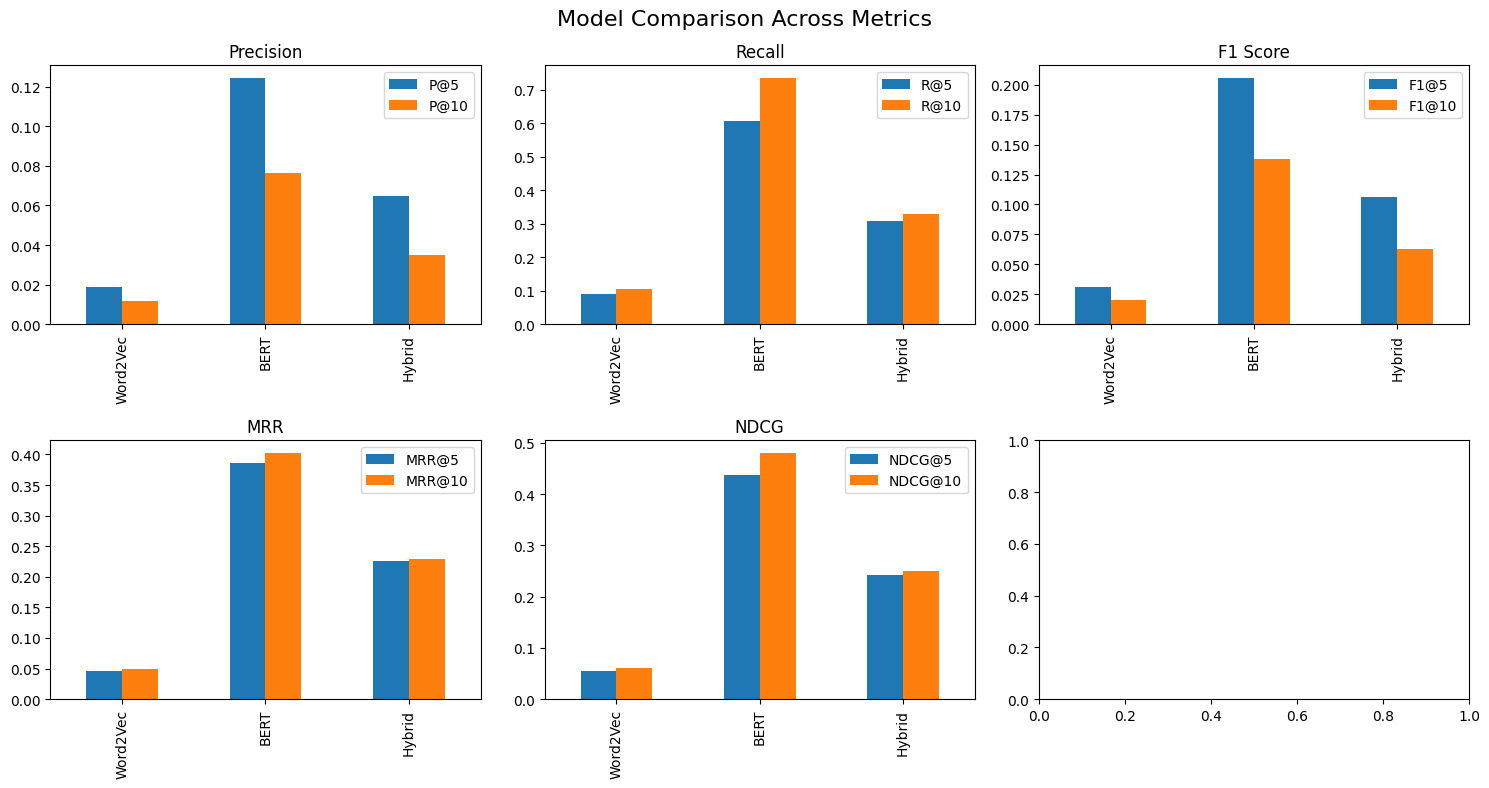

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Precision
results_metrics_df[["P@5", "P@10"]].plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("Precision")

# Recall
results_metrics_df[["R@5", "R@10"]].plot(kind="bar", ax=axes[0, 1])
axes[0, 1].set_title("Recall")

# F1
results_metrics_df[["F1@5", "F1@10"]].plot(kind="bar", ax=axes[0, 2])
axes[0, 2].set_title("F1 Score")

# MRR
results_metrics_df[["MRR@5", "MRR@10"]].plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("MRR")

# NDCG
results_metrics_df[["NDCG@5", "NDCG@10"]].plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("NDCG")


plt.suptitle("Model Comparison Across Metrics", fontsize=16)
plt.tight_layout()
plt.show()

From the evaluation plots, it is evident that SBERT consistently outperforms both Word2Vec and Hybrid models across all metrics. SBERT achieves the highest Precision, Recall, MRR, and NDCG values, indicating its strong ability to capture semantic relationships between queries and passages.

The Hybrid model performs better than Word2Vec but does not reach the performance of SBERT. This suggests that while reranking improves retrieval quality, the initial candidate retrieval stage limits its overall effectiveness.

Word2Vec performs the weakest, especially in precision-based metrics, due to its inability to capture contextual meaning effectively.

###**Expansion Experiment**

In [ ]:
def run_expansion_experiment(queries,ground_truth,n_values=(3, 5, 10),
                             k_values=(5, 10),max_queries=500):
    """
    Temporarily changes encoder.expansion_topn for each N,
    evaluates the Word2Vec model, then restores the original value.
    """

    original_topn = encoder.expansion_topn
    expansion_results = {}

    for n in n_values:
        print(f"\nExpansion N = {n} ...")
        encoder.expansion_topn = n

        res = evaluate_model(
            search_fn=search,  queries=queries,
            ground_truth=ground_truth,
            k_values=k_values,
            max_queries=max_queries,
        )

        expansion_results[f"N={n}"] = res

    encoder.expansion_topn = original_topn
    print(f"\nRestored encoder.expansion_topn = {original_topn}")

    return expansion_results

In [ ]:
def expansion_to_dataframe(expansion_results):
    return pd.DataFrame(expansion_results).T

In [ ]:
exp_results = run_expansion_experiment(queries=queries,ground_truth=ground_truth,
    k_values=(5, 10),max_queries=500)

exp_df = expansion_to_dataframe(exp_results)
exp_df.round(4)


Expansion N = 3 ...
[100/500] processed | skipped: 43
[300/500] processed | skipped: 109
[400/500] processed | skipped: 151
[500/500] processed | skipped: 195

Evaluation complete
Evaluated queries : 305
Skipped queries   : 195

Expansion N = 5 ...
[100/500] processed | skipped: 43
[300/500] processed | skipped: 109
[400/500] processed | skipped: 151
[500/500] processed | skipped: 195

Evaluation complete
Evaluated queries : 305
Skipped queries   : 195

Expansion N = 10 ...
[100/500] processed | skipped: 43
[300/500] processed | skipped: 109
[400/500] processed | skipped: 151
[500/500] processed | skipped: 195

Evaluation complete
Evaluated queries : 305
Skipped queries   : 195

Restored encoder.expansion_topn = 5


,P@5,R@5,F1@5,MRR@5,NDCG@5,P@10,R@10,F1@10,MRR@10,NDCG@10,n_evaluated,n_skipped
N=3,0.0223,0.1060,0.0366,0.0629,0.0721,0.0151,0.1421,0.0271,0.0673,0.0840,305.0,195.0
N=5,0.0190,0.0896,0.0311,0.0465,0.0555,0.0115,0.1060,0.0206,0.0488,0.0611,305.0,195.0
N=10,0.0125,0.0601,0.0205,0.0359,0.0407,0.0098,0.0929,0.0177,0.0406,0.0513,305.0,195.0


In [ ]:

exp_df = expansion_to_dataframe(exp_results)
exp_df.round(4)

,P@5,R@5,F1@5,MRR@5,NDCG@5,P@10,R@10,F1@10,MRR@10,NDCG@10,n_evaluated,n_skipped
N=3,0.0223,0.1060,0.0366,0.0629,0.0721,0.0151,0.1421,0.0271,0.0673,0.0840,305.0,195.0
N=5,0.0190,0.0896,0.0311,0.0465,0.0555,0.0115,0.1060,0.0206,0.0488,0.0611,305.0,195.0
N=10,0.0125,0.0601,0.0205,0.0359,0.0407,0.0098,0.0929,0.0177,0.0406,0.0513,305.0,195.0


In [ ]:
metric_cols = [
    "P@5", "R@5", "F1@5", "MRR@5", "NDCG@5",
    "P@10", "R@10", "F1@10", "MRR@10", "NDCG@10"
]
exp_metrics_df = exp_df[metric_cols].copy()

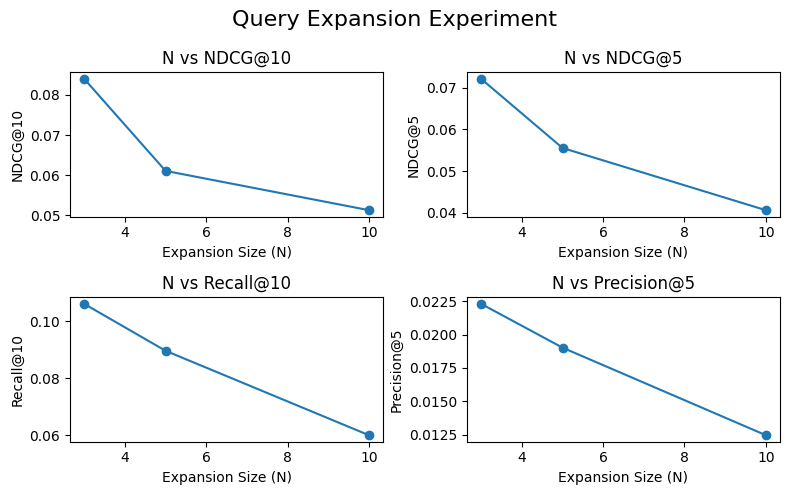

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(8, 5))

# Convert index to numeric N
exp_plot_df = exp_metrics_df.copy()
exp_plot_df.index = [int(x.split("=")[1]) for x in exp_plot_df.index]
exp_plot_df = exp_plot_df.sort_index()

# NDCG@10
axes[0,0].plot(exp_plot_df.index, exp_plot_df["NDCG@10"], marker="o")
axes[0,0].set_title("N vs NDCG@10")
axes[0,0].set_xlabel("Expansion Size (N)")
axes[0,0].set_ylabel("NDCG@10")

# NDCG@10
axes[0,1].plot(exp_plot_df.index, exp_plot_df["NDCG@5"], marker="o")
axes[0,1].set_title("N vs NDCG@5")
axes[0,1].set_xlabel("Expansion Size (N)")
axes[0,1].set_ylabel("NDCG@5")

# Precision@5
axes[1,1].plot(exp_plot_df.index, exp_plot_df["P@5"], marker="o")
axes[1,1].set_title("N vs Precision@5")
axes[1,1].set_xlabel("Expansion Size (N)")
axes[1,1].set_ylabel("Precision@5")

axes[1,0].plot(exp_plot_df.index, exp_plot_df["R@5"], marker="o")
axes[1,0].set_title("N vs Recall@10")
axes[1,0].set_xlabel("Expansion Size (N)")
axes[1,0].set_ylabel("Recall@10")
plt.suptitle("Query Expansion Experiment", fontsize=16)
plt.tight_layout()
plt.show()

The query expansion experiment shows that increasing expansion size (N) leads to a decrease in performance. Both Precision@5 and NDCG@10 decrease as N increases from 3 to 10.

This indicates that larger expansions introduce noise and reduce retrieval quality. Therefore, a smaller expansion size (N=3) provides the best balance between recall and precision.

###**Time comparision for 3 models**

In [ ]:
def search_hybrid_100(query, k=10):
    return search_hybrid(query, k=k, rerank_k=100)

In [ ]:
import time
import random
import pandas as pd

def compare_single_random_query(query, k=10):
    # randomly choose one query

    qtext = query

    results = []

    # Word2Vec
    start = time.perf_counter()
    _ = search(qtext, k=k)
    end = time.perf_counter()
    results.append({
        "Method": "Word2Vec",
        "Query": qtext,
        "Time_ms": (end - start) * 1000
    })

    # Hybrid
    start = time.perf_counter()
    _ = search_hybrid_100(qtext, k=k)
    end = time.perf_counter()
    results.append({
        "Method": "Hybrid",
        "Query": qtext,
        "Time_ms": (end - start) * 1000
    })

    # SBERT
    start = time.perf_counter()
    _ = search_sbert(qtext, k=k)
    end = time.perf_counter()
    results.append({
        "Method": "SBERT",
        "Query": qtext,
        "Time_ms": (end - start) * 1000
    })

    df = pd.DataFrame(results).sort_values("Time_ms")
    return df

In [ ]:
query="what are the best iits in india?"
speed_df = compare_single_random_query(query, k=5)
speed_df

,Method,Query,Time_ms
0,Word2Vec,what are the best iits in india?,933.285715
1,Hybrid,what are the best iits in india?,1146.743541
2,SBERT,what are the best iits in india?,1622.997113


The time comparison shows that Word2Vec is the fastest method, followed by the Hybrid model, while SBERT has the highest latency.

This is expected as SBERT performs deep semantic encoding, which is computationally expensive. The Hybrid model balances performance and efficiency by combining fast retrieval with semantic reranking.

## Final conclusions:

**Speed: Word2Vec > Hybrid > SBERT**

**Accuracy: SBERT > Hybrid > Word2Vec**

The results demonstrate a trade-off between efficiency and accuracy. Word2Vec provides fast retrieval but lacks semantic depth. SBERT achieves the best performance but is computationally expensive. The Hybrid approach improves performance by combining efficient retrieval with semantic re-ranking, making it a practical compromise for real-world systems.

##**Limitations**

The hybrid model depends heavily on the quality of the initial Word2Vec retrieval. If relevant documents are not retrieved in the first stage, the reranking step cannot recover them. Additionally, query expansion introduces noise when applied excessively, reducing performance.

# **web app using gradio**

In [ ]:
import gradio as gr
import time

def run_search(query, method, top_k):
    if not query.strip():
        return "Please enter a search query."

    try:
        start_time = time.time()

        # Calling your specific project functions
        if method == "Design 1: Word2Vec + Expansion":
            results = search(query, k=top_k)
        elif method == "Design 2: SBERT (Bi-Encoder)":
            results = search_sbert(query, k=top_k)
        else:
            # We use 100 candidates for a fast but accurate hybrid demo
            results = search_hybrid(query, k=top_k, rerank_k=300)

        end_time = time.time()
        latency = (end_time - start_time) * 1000 # convert to ms

        if not results:
            return f"### No results found.\n*Search took {latency:.2f} ms*"

        # Formatting the Web View
        md_output = f"## Results using {method}\n"
        md_output += f"⏱️ **Latency:** {latency:.2f} ms\n\n"

        for r in results:
            md_output += f"### Rank {r['rank']} (Score: {r['score']:.4f})\n"
            md_output += f"> {r['text']}\n\n"
            md_output += "---\n"

        return md_output

    except Exception as e:
        return f"### ❌ Error\n{str(e)}\n\n*Make sure all models and memmap files are loaded in previous cells!*"

# Building the Interface
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🔍 MS MARCO Semantic Search")
    gr.Markdown("Compare Design 1 (Word2Vec), Design 2 (SBERT), and Design 3 (Hybrid).")

    with gr.Row():
        with gr.Column(scale=3):
            query_input = gr.Textbox(label="Query", placeholder="Enter search terms...", lines=1)
        with gr.Column(scale=1):
            method_dropdown = gr.Dropdown(
                choices=["Design 1: Word2Vec + Expansion", "Design 2: SBERT (Bi-Encoder)", "Design 3: Hybrid"],
                value="Design 3: Hybrid",
                label="Method"
            )
            k_slider = gr.Slider(1, 10, value=5, step=1, label="Top K")

    btn = gr.Button("Search", variant="primary")
    output = gr.Markdown()

    btn.click(run_search, [query_input, method_dropdown, k_slider], output)

# share=True is ESSENTIAL in Colab for the public link
demo.launch(share=True, debug=True)

/tmp/ipykernel_4762/2429001732.py:41: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://4608c7bc1a16ccfb1e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


##Final conclusion

In conclusion, SBERT provides the best retrieval performance, while Word2Vec offers speed advantages. The Hybrid model balances both aspects, making it suitable for practical applications. The study highlights the importance of semantic embeddings and efficient retrieval strategies in modern information retrieval systems.